# Evaluation Metrics for Machine Learning Models

## Overview
This notebook presents a comprehensive implementation of **Evaluation Metrics for Machine Learning Models**. It demonstrates the fundamental mechanics and technical approaches used to solve problems within this domain.

## Objectives
- Implement and thoroughly analyze various classification metrics (Precision, Recall, F1-Score, ROC-AUC).
- Understand the tradeoffs between false positives and false negatives.
- Select the most appropriate metric based on business or technical requirements.


##Objective:

Understand the challenges of evaluating binary classifiers on imbalanced real-world datasets and learn how to use the F1 score to assess the performance of logistic regression models effectively.




--

## Goals
In this implementation, you will:

- Implement a logistic regression classifier on a real-world dataset.
- Evaluate the model using **accuracy**.
- Analyze the dataset to discover potential issues affecting model performance.
- Learn how to calculate and interpret **precision** and **recall**.
- Understand why certain evaluation metrics may be more appropriate than others.
- Apply resampling techniques to address any issues discovered.
- Visualize model performance using **Precision-Recall** and **ROC** curves.


First, we will import the necessary libraries and functions that we will use:

- **Pandas** for data manipulation and analysis.
- **NumPy** for numerical computations.
- **Scikit-learn** functions:
  - `LogisticRegression` for building the logistic regression model.
  - Evaluation metrics like `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `confusion_matrix`, `classification_report`.
  - `train_test_split` for splitting the dataset.
  - `StandardScaler` for feature scaling.
- **Matplotlib** and **Seaborn** for data visualization.
- **Imbalanced-learn** library (installed later if needed).


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For model building and evaluation
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Set seaborn style
sns.set_style('whitegrid')


## 1. Load the Dataset

We will use the **Credit Card Fraud Detection** dataset, which contains transactions made by credit card holders. Our goal is to build a model that can predict whether a transaction is fraudulent or not.

--**Instructions:**

- Download the  data file `creditcard.csv`, to your harddrive, and then you can load it into the temporal workspace of Colab (see what you did in Lab 1 for further instructions).
- Next, load the dataset into a Pandas DataFrame.
- Display the first few rows of the dataset to get an initial understanding.



## 2. Data Preprocessing

Before building the model, we need to preprocess the data.

--**Instructions:**

- Check for missing values.
- Scale the 'Amount' and 'Time' features using `StandardScaler`.
- Drop the original 'Amount' and 'Time' columns.


In [ ]:
# Load the dataset
data = pd.read_csv('Files Required/creditcard.csv')
data.head()


In [ ]:
# Check for missing values
print("Missing values in each column:")
print(data.isnull().sum())

# Feature Scaling
scaler = StandardScaler()

# Scale 'Amount' and 'Time'
data['Amount_Scaled'] = scaler.fit_transform(data['Amount'].values.reshape(-1, 1))
data['Time_Scaled'] = scaler.fit_transform(data['Time'].values.reshape(-1, 1))

# Drop original 'Amount' and 'Time' columns
data.drop(['Amount', 'Time'], axis=1, inplace=True)


Missing values in each column:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


## 3. Define Features and Target Variable

--**Instructions:**

- Separate the dataset into features `X` and target variable `y`.


In [ ]:
# Features and target variable
X = data.drop('Class', axis=1)
y = data['Class']


## 4. Split the Dataset

--**Instructions:**

- Split the dataset into training and testing sets using `train_test_split`.
- Use a test size of 20% and set `random_state` to 42 for reproducibility.


In [ ]:
# Split the dataset into training and testing sets
# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

## 5. Build and Train the Logistic Regression Model

--**Instructions:**

- Initialize a logistic regression classifier.
- Train the classifier on the training data.


In [ ]:
# Initialize the classifier
clf = LogisticRegression()

# Train the classifier

clf.fit(X_train, y_train)


LogisticRegression()

## 6. Evaluate the Model Using Accuracy

Now that we've trained our model, let's evaluate its performance.

--**Instructions:**

- Use the trained model to make predictions on the test set.
- Calculate the **accuracy** of the model.
- Print out the accuracy score.


In [ ]:

# Make predictions on the test set
y_pred = clf.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Print accuracy
print(f"Accuracy of the model: {accuracy:.6f}")


Accuracy of the model: 0.999122


### Question 1:

- Is the accuracy score obtained a good indicator of the model's performance? Why or why not?

--

**No, the accuracy score of 99.91 % obtained from the model is not a good indicator of performance in this specific case. As we know, accuracy can be misleading for imbalanced datasets like this one above **
**(credit card fraud).A model can achieve a very high accuracy by simply predicting the majority class (non-fraudulent transactions) most of the time,**
**while still performing poorly at identifying the crucial minority class (actual fraudulent transactions) which is often the primary goal.**


## 7. Analyze the Dataset

To better understand the model's performance, let's explore the dataset.

--**Instructions:**

- Check the distribution of the target variable `Class`.
- Visualize the class distribution using a count plot.


Class distribution:
Class
0    28438
1       43
Name: count, dtype: int64


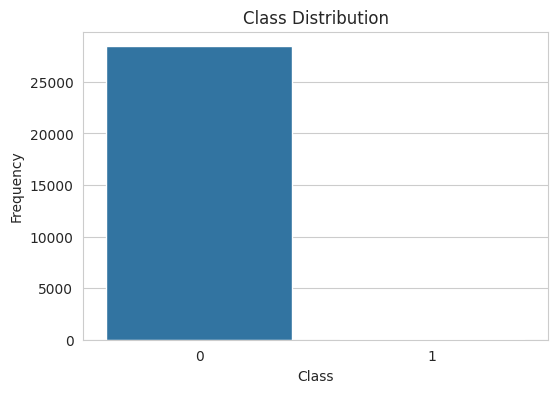

In [ ]:
# Check the distribution of the target variable
print("Class distribution:")
print(y.value_counts())

# Visualize the class distribution
plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.show()


Class distribution:
Class
0    5690
1       7
Name: count, dtype: int64


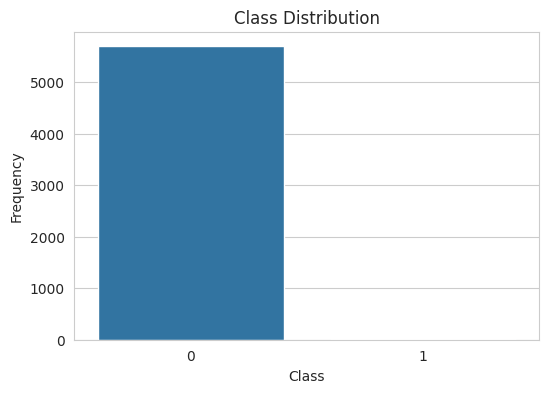

In [ ]:
# Check the distribution only for the Test set
print("Class distribution:")
print(y_test.value_counts())

# Visualize the class distribution
plt.figure(figsize=(6,4))
sns.countplot(x=y_test)
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.show()

### Question 2:

- What do you observe about the class distribution?

- How might this affect the model's performance and the evaluation metric we chose?

--


**
The class distribution analysis  and the count plot clearly shows a severe imbalance. There are 28438 non-fraudulent transactions (Class 0) nd only 43 fraudulent transactions (Class 1)  **
** in the dataset used (or 5690 vs 7 in the test set).This imbalance makes accuracy a poor metric. The model is likely biased towards predicting the majority class (non-fraud). **
**While this leads to high accuracy, it means the model might perform poorly at detecting the crucial minority class (fraud), as indicated by other metrics like recall.
**


## 8. Evaluate the Model Using Confusion Matrix

The confusion matrix provides a more detailed breakdown of model performance.

--**Instructions:**

- Compute the confusion matrix for the test predictions.
- Display the confusion matrix using a heatmap.


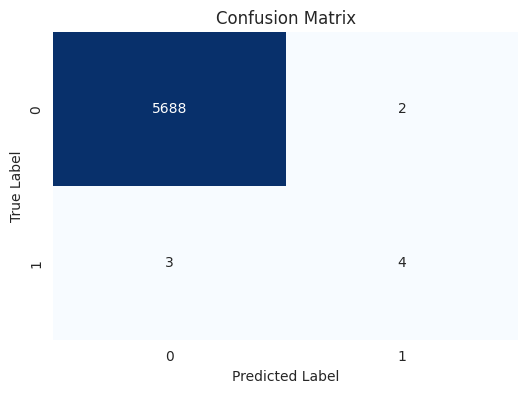

Confusion Matrix:
[[5688    2]
 [   3    4]]


In [ ]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix using heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Print confusion matrix values
print("Confusion Matrix:")
print(cm)


### Question 3:

- Based on the confusion matrix, how many fraudulent transactions did the model correctly identify?
- How many did it miss?
- Does this align with the high accuracy score obtained earlier?

--**Reflect on these questions before proceeding.**



**
Correctly Identified (True Positives - TP): Looking at the confusion matrix in  the model correctly identified 4 fraudulent transactions.  **

** Missed (False Negatives - FN) shows the model missed 3 fraudulent transactions.
**

**Alignment with Accuracy: No, this does not align well with the high accuracy. The accuracy score suggested near-perfect performance, but the confusion matrix
**
**reveals the model failed to catch 3 out of the 7 actual fraud cases in the test set. This further demonstrates why accuracy is misleading here.
**



## 9. Evaluate the Model Using Precision and Recall

Accuracy may not be sufficient for imbalanced datasets. Let's calculate **precision** and **recall** to get a better understanding.

--**Instructions:**

- Calculate the **precision** and **recall** of the model (set zero_division to 0).
- Print out the precision and recall scores.


In [ ]:
from sklearn.metrics import precision_score, recall_score

# Calculate precision and recall
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)

# Print precision and recall
print(f"Precision of the model: {precision:.6f}")
print(f"Recall of the model: {recall:.6f}")


Precision of the model: 0.666667
Recall of the model: 0.571429


### Question 4:

- What do the precision and recall scores tell you about the model's performance?

- Why might these metrics be more informative than accuracy in this context?

**Precision (0.6667 or 66.7%): This score tells us that of all the transactions the model predicted as fraudulent, 66.7% were actually fraudulent. The remaining 33.3% were false positives (incorrectly flagged as fraud). **

**Recall (0.5714 or 57.1%): This score indicates that the model successfully identified 57.1% of all the actual fraudulent transactions present in the test set. It failed to detect (missed) the other 42.9% of actual frauds.
**

**Why More Informative: Precision and recall focus specifically on the performance related to the positive class (fraud). Recall is particularly important here as it tells us how effective the model is at finding the fraudulent cases, which is critical.
**

**Accuracy gets inflated by the large number of correctly identified negative cases (non-fraud) and obscures the poor performance on the minority class.**


## 10. Understanding Precision and Recall

- **Precision** measures the proportion of positive identifications that were actually correct.
- **Recall** measures the proportion of actual positives that were identified correctly.

In the context of fraud detection:

- **Precision** answers: "Of all transactions predicted as fraudulent, how many were actually fraudulent?"
- **Recall** answers: "Of all actual fraudulent transactions, how many did the model detect?"

--Given the low recall score, our model is missing many fraudulent transactions.


## 11. Improving the Model

One way to address the issue of class imbalance is to apply resampling techniques.

--**Instructions:**

- Install the `imbalanced-learn` library.
- Use **Synthetic Minority Over-sampling Technique (SMOTE)** to balance the classes in the training set.


In [ ]:
# Install imbalanced-learn library
!pip install imbalanced-learn

# Import SMOTE
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Resample the training data
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Check the new class distribution
print("Resampled class distribution:")
print(pd.Series(y_resampled).value_counts())


Resampled class distribution:
Class
0    22748
1    22748
Name: count, dtype: int64


## 12. Re-train the Model on Resampled Data

--**Instructions:**

- Initialize a new logistic regression classifier.
- Train the classifier on the resampled training data.


In [ ]:
# Initialize the classifier
clf_resampled = LogisticRegression()

# Train the classifier
clf_resampled.fit(X_resampled, y_resampled)


LogisticRegression()

## 13. Evaluate the New Model

--**Instructions:**

- Use the new model to make predictions on the test set.
- Calculate accuracy, precision, and recall.
- Display the confusion matrix.


Accuracy of the resampled model: 0.994559
Precision of the resampled model: 0.184211
Recall of the resampled model: 1.000000


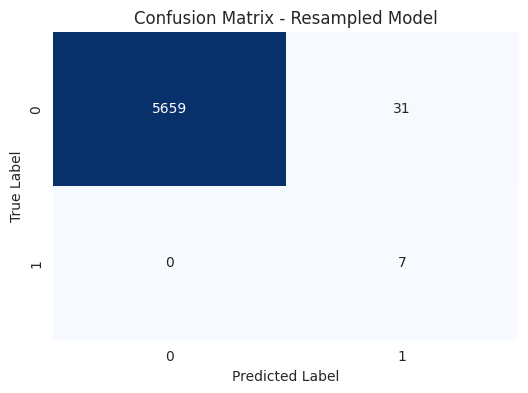

Confusion Matrix - Resampled Model:
[[5659   31]
 [   0    7]]


In [ ]:
# Make predictions on the test set
y_pred_resampled = clf_resampled.predict(X_test)

# Calculate evaluation metrics
accuracy_resampled = accuracy_score(y_test, y_pred_resampled)
precision_resampled = precision_score(y_test, y_pred_resampled, zero_division=0)
recall_resampled = recall_score(y_test, y_pred_resampled, zero_division=0)

# Print evaluation metrics
print(f"Accuracy of the resampled model: {accuracy_resampled:.6f}")
print(f"Precision of the resampled model: {precision_resampled:.6f}")
print(f"Recall of the resampled model: {recall_resampled:.6f}")

# Compute confusion matrix
cm_resampled = confusion_matrix(y_test, y_pred_resampled)

# Display confusion matrix using heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm_resampled, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Resampled Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Print confusion matrix values
print("Confusion Matrix - Resampled Model:")
print(cm_resampled)

## 14. Visualize Model Performance

Let's visualize the performance of both models using Precision-Recall and ROC curves.

--**Instructions:**

- Plot the **Precision-Recall Curve** for the resampled model.
- Plot the **ROC Curve** for the resampled model.
- Include the AUC in the plots


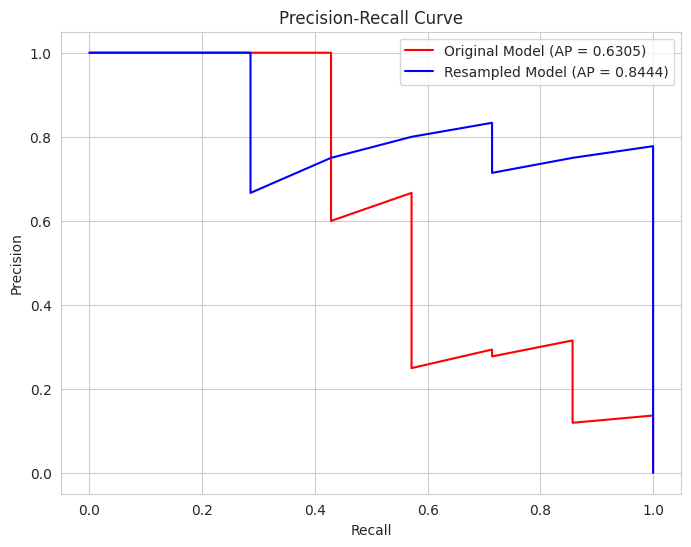

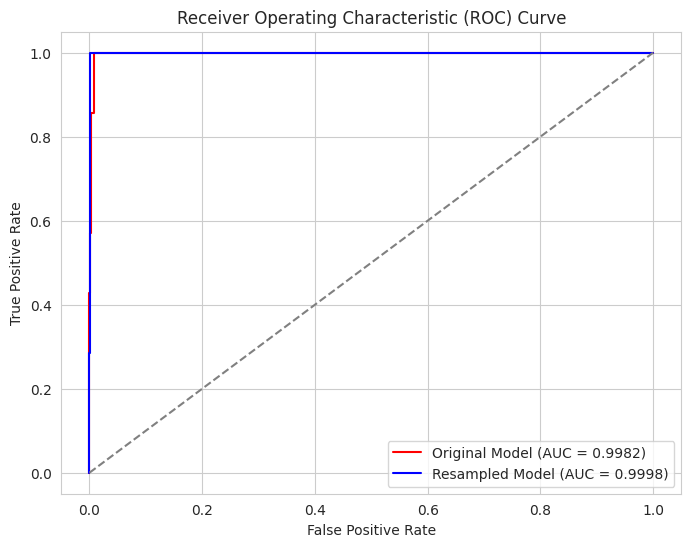

In [ ]:
from sklearn.metrics import precision_recall_curve, roc_curve, auc, average_precision_score

# Get the decision scores for both models
y_scores_original = clf.decision_function(X_test)
y_scores_resampled = clf_resampled.decision_function(X_test)

# Calculate precision-recall pairs for both models
precision_orig, recall_orig, _ = precision_recall_curve(y_test, y_scores_original)
precision_resampled, recall_resampled, _ = precision_recall_curve(y_test, y_scores_resampled)

# Calculate Average Precision (AP) scores
ap_orig = average_precision_score(y_test, y_scores_original)
ap_resampled = average_precision_score(y_test, y_scores_resampled)

# Plot the Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall_orig, precision_orig, color='r', label=f'Original Model (AP = {ap_orig:.4f})')
plt.plot(recall_resampled, precision_resampled, color='b', label=f'Resampled Model (AP = {ap_resampled:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

# Calculate ROC curves for both models
fpr_orig, tpr_orig, _ = roc_curve(y_test, y_scores_original)
roc_auc_orig = auc(fpr_orig, tpr_orig)

fpr_resampled, tpr_resampled, _ = roc_curve(y_test, y_scores_resampled)
roc_auc_resampled = auc(fpr_resampled, tpr_resampled)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_orig, tpr_orig, color='r', label=f'Original Model (AUC = {roc_auc_orig:.4f})')
plt.plot(fpr_resampled, tpr_resampled, color='b', label=f'Resampled Model (AUC = {roc_auc_resampled:.4f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()


### Question 6:

In the context of imbalanced datasets, is it more appropriate to evaluate model performance using the AUC of the ROC curve or the AUC of the Precision-Recall (PR) curve? Explain your reasoning.

--**Reflect on this question and consider how each metric responds to changes in class imbalance and which provides more informative insights into model performance on the minority class.**

--**Hint:**

- Think about how the **ROC curve** (Receiver Operating Characteristic curve) and its AUC (Area Under the Curve) represent the trade-off between the true positive rate and the false positive rate.
- Consider how the **Precision-Recall curve** focuses on the trade-off between precision (positive predictive value) and recall (sensitivity) and how it behaves when dealing with imbalanced classes.
- Recall that in imbalanced datasets, the number of negative instances far outweighs the number of positive instances, which can influence the interpretation of evaluation metrics.

--**For Imbalanced datasets, AUC PR is generally more appropriate than ROC AUC because ROC AUC can appear overly optimistic due to the large number of true negatives,**

 **while PR AUC provides a clearer assessment by focusing on precision and recall, which are more sensitive to performance on the rare positive class.**



## 15. Conclusion

In this implementation, we:

- Discovered that using **accuracy** as an evaluation metric on imbalanced data can be misleading.
- Learned that **precision** and **recall** provide better insights into model performance on imbalanced datasets.
- Applied **SMOTE** to address class imbalance, which improved the model's ability to detect fraudulent transactions.
- Understood the trade-offs between precision and recall.

--### Final Questions:

1. **Why is accuracy not a reliable metric for imbalanced datasets?**
**Because a model can achieve a high accuracy score simply by predicting the overwhelmingly common majority class, even if it completely fails to identify the rare but important minority class. **

2. **How do precision and recall complement each other in evaluating model performance?**
**They measure different aspects of positive class performance. Precision measures the correctness of positive predictions (minimizing false positives),**

**while Recall measures the completeness of positive predictions (minimizing false negatives). Often, improving one comes at the expense of the other (the precision-recall trade-off). Evaluating both gives a balanced view. **
3. **What are the potential downsides of resampling techniques like SMOTE?**
**A potential downside is overfitting to the synthetic minority samples, which can reduce the model's ability to generalize effectively to new, unseen real minority instances.amples, potentially not generalizing well to unseen real minority instances.**
**Increased False Positives: Improving recall dramatically through oversampling can sometimes lead to a significant drop in precision (more false positives).**
4. **In what situations might you prioritize precision over recall, or vice versa?**
**Prioritize Precision: When the cost of a False Positive is high. Examples: Spam detection (you don't want to incorrectly classify important emails as spam).**
**Prioritize Recall: When the cost of a False Negative is high. Examples: Fraud detection (missing a fraudulent transaction is very costly).**



## Additional Resources

- **Imbalanced-learn Documentation:** [https://imbalanced-learn.org/stable/](https://imbalanced-learn.org/stable/)
- **Scikit-learn Metrics and Scoring:** [https://scikit-learn.org/stable/modules/model_evaluation.html](https://scikit-learn.org/stable/modules/model_evaluation.html)
- **Precision and Recall Explained:** [https://en.wikipedia.org/wiki/Precision_and_recall](https://en.wikipedia.org/wiki/Precision_and_recall)
